In [39]:
import os
import sys
import argparse

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.environ.setdefault("RNA_STRUCT_HOME", repo_root)
sys.path.insert(0, repo_root)

In [40]:
import numpy as np
from merge_rna import Experiment, create_exp_synthetic_comb, MultiSystemsFit

## KL regularization effect on synthetic bistable fits

Compare three runs that differ only in `reg_weight`:
- **no KL (main)** — original paper fit, no KL regularization
- **KL 1e4** — `reg_weight = 10 000`
- **KL 1e6** — `reg_weight = 1 000 000`

Ground truth pairing probabilities come from `data/cache/designed_sequence/synthetic_pp_curves.csv`
(computed by `_regenerate_cache_nb4.py` from the paper reference params `pop*.txt`).

In [54]:
# Cell 1 — Setup
import pathlib
import pandas as pd
import matplotlib.pyplot as plt

REPO = pathlib.Path("..").resolve()
POP1_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

RUNS = {
    "no KL (main)":         REPO / "fits_paper/designed_sequence/outputs/synthetic_bistable_main",
    "no KL unconstrained":  REPO / "fits_paper/designed_sequence/outputs/synthetic_bistable_main_unconstrained",
    "KL 0.05":              REPO / "fits_paper/designed_sequence/outputs/synthetic_bistable_weigh_05",
    "KL 1e2":               REPO / "fits_paper/designed_sequence/outputs/synthetic_bistable_weigh_10000_ok",
    "KL 1e4":               REPO / "fits_paper/designed_sequence/outputs/synthetic_bistable_weigh_1000000"
}
COLORS = {"no KL (main)": "tab:blue", "no KL unconstrained": "tab:purple", "KL 1e2": "tab:orange", "KL 1e4": "tab:red", "KL 0.05": "tab:green"}

In [55]:
# Cell 2 — Load fitted pairing probabilities and lambda_sc from output directories
def _load_txt(path):
    """Load a comment-headed text file; return None if the file is missing."""
    if not pathlib.Path(path).exists():
        return None
    return np.loadtxt(path, comments='#')

def _subdir(run_dir, pop1):
    return run_dir / f"synthetic_bistable_{round(pop1 * 100)}" / "detailed"

pp_data  = {}   # pp_data[label][pop1]  -> 1-D array, length N_seq
lsc_data = {}   # lsc_data[label][pop1] -> 1-D array, length N_seq

for label, run_dir in RUNS.items():
    pp_data[label]  = {}
    lsc_data[label] = {}
    for pop1 in POP1_VALUES:
        sd = _subdir(run_dir, pop1)
        pp_data[label][pop1] = _load_txt(sd / "pairing_probs.txt")
        lsc_files = list(sd.glob("*lambda_sc.txt"))
        lsc_data[label][pop1] = _load_txt(lsc_files[0]) if lsc_files else None

for label in RUNS:
    n_pp  = sum(1 for p in POP1_VALUES if pp_data[label][p]  is not None)
    n_lsc = sum(1 for p in POP1_VALUES if lsc_data[label][p] is not None)
    print(f"{label:20s}  pairing_probs: {n_pp}/{len(POP1_VALUES)}  lambda_sc: {n_lsc}/{len(POP1_VALUES)}")

no KL (main)          pairing_probs: 6/6  lambda_sc: 6/6
no KL unconstrained   pairing_probs: 6/6  lambda_sc: 6/6
KL 0.05               pairing_probs: 6/6  lambda_sc: 6/6
KL 1e2                pairing_probs: 6/6  lambda_sc: 6/6
KL 1e4                pairing_probs: 6/6  lambda_sc: 6/6


In [56]:
# Cell 3 — Load ground truth pairing probabilities
# Source: data/cache/designed_sequence/synthetic_pp_curves.csv
# Built by _regenerate_cache_nb4.py from the paper reference params (pop*.txt).
CACHE_DIR = REPO / "data/cache/designed_sequence"

gt_df = pd.read_csv(CACHE_DIR / "synthetic_pp_curves.csv")

gt_pp = {}
for pop1 in POP1_VALUES:
    mask = np.isclose(gt_df['pop1'], pop1)
    if mask.any():
        gt_pp[pop1] = gt_df.loc[mask].sort_values('pos')['pp'].values
    else:
        gt_pp[pop1] = None
        print(f"WARNING: no ground truth entry for pop1={pop1}")

arc = np.load(CACHE_DIR / "synthetic_arcplot_extremes.npz", allow_pickle=True)
idx_h1 = arc['indices_helix1']
idx_h2 = arc['indices_helix2']

print(f"Ground truth loaded: {len(gt_pp)} pop1 values, {len(next(iter(gt_pp.values())))} positions")
print(f"Helix 1 positions: {idx_h1[0]}–{idx_h1[-1]}  ({len(idx_h1)} nt)")
print(f"Helix 2 positions: {idx_h2[0]}–{idx_h2[-1]}  ({len(idx_h2)} nt)")

Ground truth loaded: 6 pop1 values, 148 positions
Helix 1 positions: 38–62  (25 nt)
Helix 2 positions: 106–130  (25 nt)


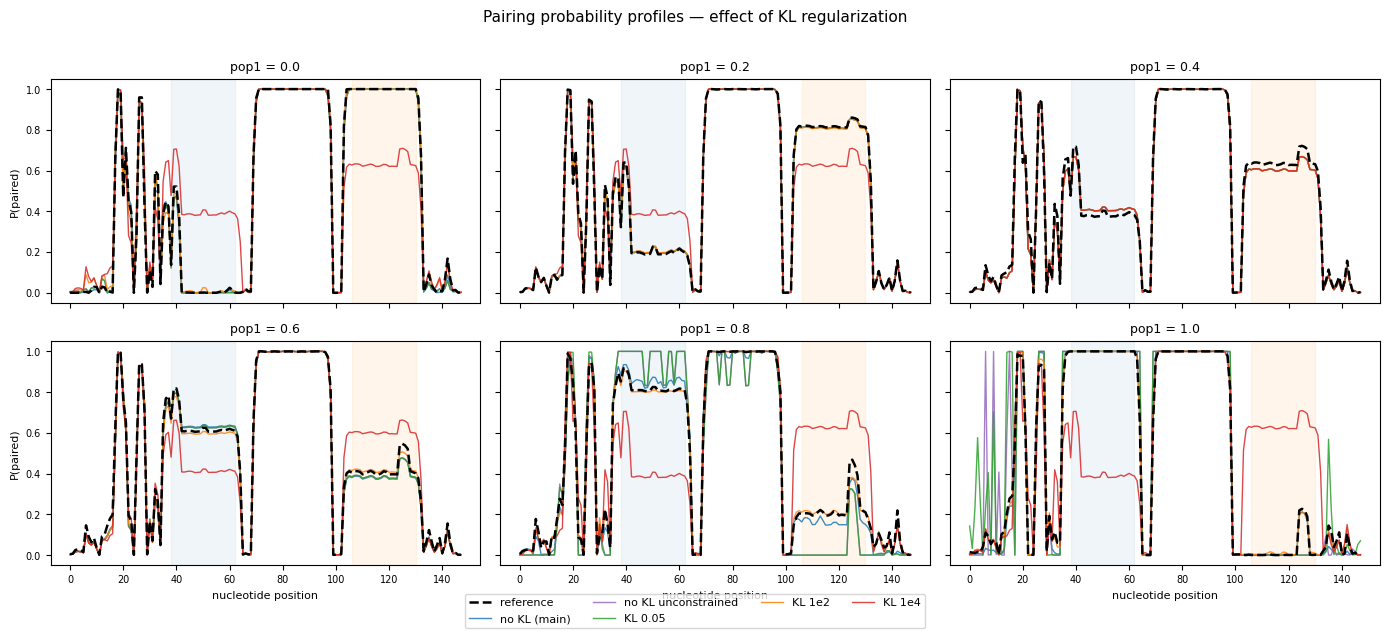

In [57]:
# Cell 4 — Figure 1: pairing probability profiles
# One subplot per pop1 (2×3 grid). Each subplot overlays all runs + ground truth.
# Vertical shading marks helix 1 (blue) and helix 2 (orange) regions.

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True, sharex=True)

for ax, pop1 in zip(axes.flatten(), POP1_VALUES):
    gt = gt_pp.get(pop1)
    if gt is not None:
        ax.plot(gt, color='black', lw=1.8, ls='--', label='reference', zorder=5)

    for label in RUNS:
        pp = pp_data[label].get(pop1)
        if pp is not None:
            ax.plot(pp, color=COLORS[label], lw=1.0, alpha=0.85, label=label)

    # shade helix regions
    for idx, fc in [(idx_h1, 'steelblue'), (idx_h2, 'darkorange')]:
        ax.axvspan(idx[0], idx[-1], alpha=0.08, color=fc)

    ax.set_title(f"pop1 = {pop1:.1f}", fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[:, 0]:
    ax.set_ylabel("P(paired)", fontsize=8)
for ax in axes[1, :]:
    ax.set_xlabel("nucleotide position", fontsize=8)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.03), frameon=True)
fig.suptitle("Pairing probability profiles — effect of KL regularization", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

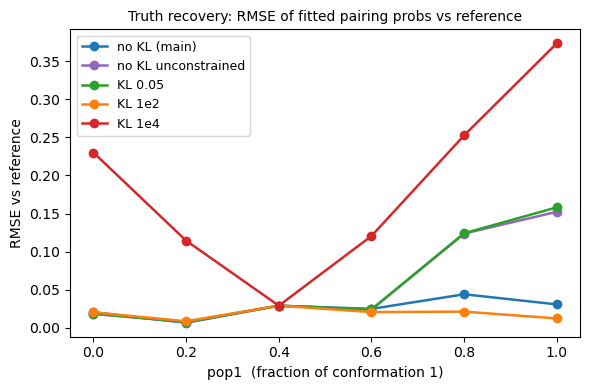

In [58]:
# Cell 5 — Figure 2: truth recovery (RMSE vs pop1)
# RMSE between each run's fitted pairing probs and the reference (ground truth).

fig, ax = plt.subplots(figsize=(6, 4))

for label in RUNS:
    pop1_avail, rmse_vals = [], []
    for pop1 in POP1_VALUES:
        fitted = pp_data[label].get(pop1)
        gt = gt_pp.get(pop1)
        if fitted is not None and gt is not None:
            n = min(len(fitted), len(gt))
            rmse_vals.append(np.sqrt(np.mean((fitted[:n] - gt[:n]) ** 2)))
            pop1_avail.append(pop1)
    ax.plot(pop1_avail, rmse_vals, 'o-', color=COLORS[label], label=label, lw=1.8, ms=6)

ax.set_xlabel("pop1  (fraction of conformation 1)", fontsize=10)
ax.set_ylabel("RMSE vs reference", fontsize=10)
ax.set_title("Truth recovery: RMSE of fitted pairing probs vs reference", fontsize=10)
ax.set_xticks(POP1_VALUES)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

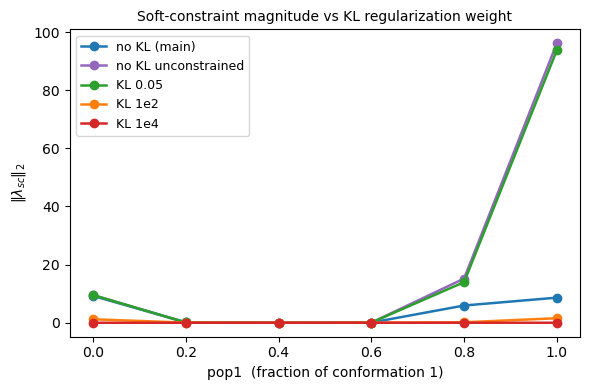

In [59]:
# Cell 6 — Figure 3: lambda_sc L2 norm vs pop1
# Shows whether KL regularization suppresses the soft constraints as expected.

fig, ax = plt.subplots(figsize=(6, 4))

for label in RUNS:
    pop1_avail, norms = [], []
    for pop1 in POP1_VALUES:
        lsc = lsc_data[label].get(pop1)
        if lsc is not None:
            norms.append(np.linalg.norm(lsc))
            pop1_avail.append(pop1)
    ax.plot(pop1_avail, norms, 'o-', color=COLORS[label], label=label, lw=1.8, ms=6)

ax.set_xlabel("pop1  (fraction of conformation 1)", fontsize=10)
ax.set_ylabel(r"$\|\lambda_{sc}\|_2$", fontsize=10)
ax.set_title(r"Soft-constraint magnitude vs KL regularization weight", fontsize=10)
ax.set_xticks(POP1_VALUES)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### KL divergence recomputed from saved files

The KL formula is `D_KL = (-λ·p_λ + (F_λ - F_0)) / kBT`, where:
- `λ` = fitted lambda_sc (from `*lambda_sc.txt`)
- `p_λ` = pairing probs under lambda_sc — needs a ViennaRNA forward pass
- `F_λ` = partition function free energy with soft constraints (same forward pass)
- `F_0` = partition function free energy with **no** soft constraints (reference distribution)

We reuse `ExperimentFit.kl_and_grad()` from `fit.py`: create one `ExperimentFit` (sequence is
identical for all pop1 values), call `get_ps(penalty, λ)` to fill its cache, then call `kl_and_grad`.

In [73]:
# Cell 7 — Recompute KL divergence using ExperimentFit.kl_and_grad()

# --- One-time setup -------------------------------------------------------
# Build params_dict_ref (same boilerplate as run_synthetic_bistable.py)
REF_PARAMS_FILE = REPO / "fits_paper/designed_sequence/synthetic/reference_physical_params.txt"
_params_1D_ref = np.loadtxt(REF_PARAMS_FILE)
_exp_ref_0mM = next(
    (Experiment(p) for p in Experiment.paths_to_redmond_ivt_data_txt
     if Experiment(p).conc_mM == 0), None)
_multi_ref = MultiSystemsFit([_exp_ref_0mM], validation_exps=None,
                              infer_1D_sc=False, skip_output_setup=True)
_params_dict_ref = _multi_ref.pack_params(_params_1D_ref, _multi_ref.systems[0])

# Create ONE ExperimentFit: all pop1 values share the same sequence (148 nt)
_exp0 = create_exp_synthetic_comb(pop1=0.0, same_system=True, params_dict=_params_dict_ref)
_multi0 = MultiSystemsFit([_exp0], infer_1D_sc=True, skip_output_setup=True)
_exp_fit = _multi0.systems[0].exp_fits_all[0]

# Compute penalty once: physical params are identical across all runs (verified),
# conc_mM = 50 mM for all synthetic experiments.
_params_1D_any = np.loadtxt(list(RUNS.values())[0] / "synthetic_bistable_0" / "params1D.txt")
_p = _multi0.pack_params(_params_1D_any, _multi0.systems[0])
_mu_j = _p['mu_r'] + _exp_fit.kBT * np.log((50.0 + 0.1) / 1000)
_penalty = _exp_fit.compute_penalty_m(_mu_j, _p['p_b'])
print(f"Penalty (shared): {_penalty:.4f} kcal/mol")

# --- KL computation --------------------------------------------------------
kl_data = {}
for label, run_dir in RUNS.items():
    kl_data[label] = {}
    for pop1 in POP1_VALUES:
        lsc = lsc_data[label].get(pop1)
        if lsc is None:
            kl_data[label][pop1] = None
            continue
        _exp_fit.get_ps(_penalty, lsc)                           # fills cache (p_sb, F_lam)
        kl, _ = _exp_fit.kl_and_grad(lsc, compute_gradient=False)
        kl_data[label][pop1] = float(kl)
        print(f"  {label:20s} | pop1={pop1:.1f}: KL = {kl:.4f}")

Penalty (shared): 0.0105 kcal/mol
  no KL (main)         | pop1=0.0: KL = 65.5656
  no KL (main)         | pop1=0.2: KL = 1.0097
  no KL (main)         | pop1=0.4: KL = 0.0000
  no KL (main)         | pop1=0.6: KL = 0.9621
  no KL (main)         | pop1=0.8: KL = 29.9356
  no KL (main)         | pop1=1.0: KL = 72.1553
  no KL unconstrained  | pop1=0.0: KL = 62.3642
  no KL unconstrained  | pop1=0.2: KL = 0.6708
  no KL unconstrained  | pop1=0.4: KL = 0.0000
  no KL unconstrained  | pop1=0.6: KL = 0.5479
  no KL unconstrained  | pop1=0.8: KL = 75.3147
  no KL unconstrained  | pop1=1.0: KL = 685.8050
  KL 0.05              | pop1=0.0: KL = 62.4082
  KL 0.05              | pop1=0.2: KL = 0.6703
  KL 0.05              | pop1=0.4: KL = 0.0000
  KL 0.05              | pop1=0.6: KL = 0.5482
  KL 0.05              | pop1=0.8: KL = 70.0735
  KL 0.05              | pop1=1.0: KL = 704.0557
  KL 1e2               | pop1=0.0: KL = 8.6308
  KL 1e2               | pop1=0.2: KL = 0.5076
  KL 1e2       

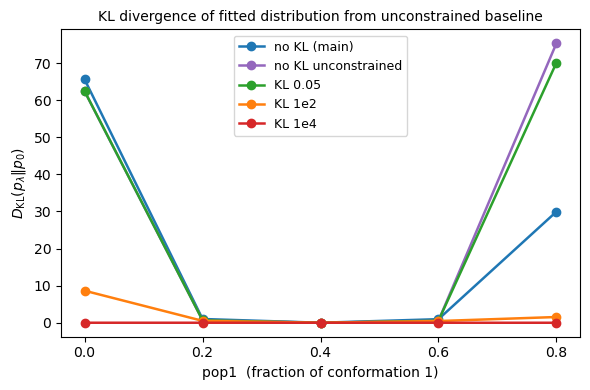

In [77]:
# Cell 8 — Figure 4: KL divergence vs pop1 for each run
fig, ax = plt.subplots(figsize=(6, 4))

for label in RUNS:
    pop1_avail, kl_vals = [], []
    for pop1 in POP1_VALUES[0:5]:
        kl = kl_data[label].get(pop1)
        if kl is not None:
            pop1_avail.append(pop1)
            kl_vals.append(kl)
    ax.plot(pop1_avail, kl_vals, 'o-', color=COLORS[label], label=label, lw=1.8, ms=6)

ax.set_xlabel("pop1  (fraction of conformation 1)", fontsize=10)
ax.set_ylabel(r"$D_\mathrm{KL}(p_\lambda \| p_0)$", fontsize=10)
ax.set_title("KL divergence of fitted distribution from unconstrained baseline", fontsize=10)
ax.set_xticks(POP1_VALUES[0:5])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()